# Reproducing the figures, step by step

This notebook walks through everything the paper's figures are made of: the
color-space conversions, the stimulus construction, the detection model, and
then each of the ten figures.

It is a tutorial, not a second implementation. The concepts are worked through
inline so you can see what each step does; the figures themselves are produced
by running the same scripts in `figures/` that made the ones in the manuscript,
so what you get here is pixel-identical to what is printed.

**What is not here.** The per-trial responses are not part of this repository
(see the README). What is published is the condition level: for each condition,
how many trials were run over all observers and on how many flicker was
reported. Everything below works from that.

In [1]:
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = os.path.abspath(".")
sys.path.insert(0, os.path.join(ROOT, "figures"))
from _paths import DATA, OUT, SHARE, CODES, MN, conditions, load_json

print("repository :", ROOT)
print("data       :", os.listdir(DATA))

repository : C:\Users\yuich\Documents\2026_research\vibrosaliency-perception\color-vibration-amplitude-budget
data       : ['axes_fit.json', 'conditions.json', 'fine_loci.json', 'results_data.json']


## 1. What the experiment measured

22 observers each saw 240 trials. On every trial a $2^\circ$ patch at the
center of the field alternated between two colors at 22.5 Hz, and the observer
reported whether any flicker was visible. The stimuli came in three systems:

| System | What it varies | Conditions |
|---|---|---|
| A | a MacAdam ellipse and a radius $r$ along it | 18 |
| B | $a_{\mathrm{RG}} \times a_{\mathrm{S}}$ on a grid | 18 |
| C | $a_{\mathrm{Lum}} \times a_{\mathrm{RG}}$ on a grid | 25 |

`data/conditions.json` has one entry per condition.

In [2]:
doc = json.load(open(os.path.join(DATA, "conditions.json"), encoding="utf-8"))
print("observers        :", doc["n_observers"])
print("stimulus trials  :", doc["n_stimulus_trials"])
print("catch trials     : %d, false alarms %d (%.3f)"
      % (doc["catch"]["n_trials"], doc["catch"]["n_detected"],
         doc["catch"]["false_alarm_rate"]))
print()

row = conditions("A")[0]
for k, v in row.items():
    print("   %-12s %s" % (k, v))

observers        : 22
stimulus trials  : 4818
catch trials     : 462, false alarms 21 (0.045)

   block        A
   n_trials     88
   n_detected   6
   p            0.06818181818181818
   nom_Lum      0.0
   nom_RG       0.0229
   nom_S        0.1753
   c1           [0.18782077729701996, 0.4793201684951782, 0.23839756846427917]
   c2           [0.11697066575288773, 0.4910208582878113, 0.37123769521713257]
   ellipse      8
   radius       10
   ci95         [0.0, 0.1590909090909091]


`c1` and `c2` are the two linear display values the condition alternated
between, exactly as the presentation software recorded them. Everything else in
the paper is computed from those two numbers plus the counts.

## 2. From two display colors to three amplitudes

The pair is described by what it does to the three cone-opponent pathways. Take
the two colors to LMS cone excitations, form the contrast of each cone class
against the mean of the pair, and combine:

$$a_{\mathrm{Lum}} = |c_L + c_M|, \qquad
  a_{\mathrm{RG}}  = |c_L - c_M|, \qquad
  a_{\mathrm{S}}   = \left|c_S - \tfrac{c_L + c_M}{2}\right|$$

A pair is *cone-isoluminant* when $a_{\mathrm{Lum}} = 0$: the two colors differ,
but the sum of the L and M signals does not move.

In [3]:
import cfvi as C          # code/share/cfvi.py, already on sys.path via _paths


def amplitudes(c1, c2):
    'The three cone-opponent amplitudes of one color pair.'
    la, ls = C.rgb_to_lms(np.array(c1)), C.rgb_to_lms(np.array(c2))
    m = (la + ls) / 2.0
    cL, cM, cS = (la - ls) / np.where(m > 1e-9, m, 1e-9)
    return (abs((cL + cM) / 2), abs(cL - cM) / 2, abs(cS - (cL + cM) / 2) / 2)


for row in conditions("A")[:4]:
    a = amplitudes(row["c1"], row["c2"])
    print("E%-3d r=%-3d  a_Lum %.5f   a_RG %.4f   a_S %.4f   P(A) %.3f"
          % (row["ellipse"], row["radius"], a[0], a[1], a[2], row["p"]))

E8   r=10   a_Lum 0.00031   a_RG 0.0228   a_S 0.1803   P(A) 0.068
E8   r=20   a_Lum 0.00508   a_RG 0.0470   a_S 0.3440   P(A) 0.159
E8   r=30   a_Lum 0.00267   a_RG 0.0715   a_S 0.4965   P(A) 0.284
E8   r=35   a_Lum 0.00201   a_RG 0.0843   a_S 0.5646   P(A) 0.420


Note how small $a_{\mathrm{Lum}}$ is across system A: those pairs were built to
be cone-isoluminant, and the residual is the 8-bit quantization of the
framebuffer, not a design choice.

In [4]:
worst = max(amplitudes(r["c1"], r["c2"])[0] for r in conditions("A"))
print("largest residual a_Lum over all 18 system-A conditions: %.5f" % worst)

largest residual a_Lum over all 18 system-A conditions: 0.00643


## 3. The stimulus construction

This is the part worth reading closely. Given a MacAdam ellipse and a radius
$r$, we need the pair of display colors that sits at that radius and is
cone-isoluminant. Four steps:

1. Carry the ellipse from the $xy$ plane to the CIE 1960 $uv$ plane, where
   equal distances correspond more nearly to equal discriminability.
2. Find the direction $\theta$ out of the ellipse center along which the two
   sides are equal in **chroma** under CAM16 with the Helmholtz–Kohlrausch
   correction — so the pair does not differ in apparent colorfulness.
3. Step out to $r$ times the ellipse radius in that direction, giving the two
   chromaticities.
4. Adjust the luminance split $\Delta Y$ until the pair is cone-isoluminant.

Steps 2 and 4 interact, so they are solved as a nested Newton iteration.

In [5]:
sys.path.insert(0, CODES)
import macadam_newton as mn
import macadam_newton_cam16hk as hk

E, R = 12, 30                                   # ellipse 12 at radius 30

# step 1: the ellipse in uv
u0, v0, a_uv, b_uv, ang = mn.transform_ellipse(*mn.ELLIPSE_XY[E])
print("ellipse %d  center xy = (%.3f, %.3f)" % (E, *mn.ELLIPSE_XY[E][:2]))
print("           center uv = (%.4f, %.4f)  semi-axes (%.5f, %.5f) at %.1f deg"
      % (u0, v0, a_uv, b_uv, ang))

# step 2: the equal-chroma direction, and step 3: the half-distance
grad = hk.compute_jacobian_JHK(u0, v0)
sol = hk.solve_twostage(u0, v0, (a_uv, b_uv, ang), grad, [R])[0]
d = mn._compute_d(R, sol["theta"], (a_uv, b_uv, ang))
print("           equal-chroma direction theta = %.2f deg, uv half-distance = %.5f"
      % (sol["theta"], d))

ellipse 12  center xy = (0.305, 0.323)
           center uv = (0.1947, 0.3093)  semi-axes (0.00085, 0.00072) at -100.3 deg


           equal-chroma direction theta = 136.00 deg, uv half-distance = 0.02253


In [6]:
from scipy.optimize import brentq
import importlib.util


def load_as(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(m)
    return m


cf = load_as("cfvi_codes", os.path.join(CODES, "cfvi.py"))   # decompose, xyz2lin
Y0 = 0.4
th = np.deg2rad(sol["theta"])


def pair_at(dY):
    'The two linear display colors, with a luminance split of dY.'
    out = []
    for s in (+1, -1):
        u, v = u0 + s * d * np.cos(th), v0 + s * d * np.sin(th)
        x, y = mn.uv_to_xy(u, v)
        out.append(cf.xyz2lin(mn.xy_to_XYZ(x, y, Y0 + s * dY)))
    return out


# step 4: choose dY so that a_Lum is zero
dY = brentq(lambda t: cf.decompose(*pair_at(t))[0], -0.2, 0.2, xtol=1e-7)
c1, c2 = pair_at(dY)
print("luminance split dY = %+.6f" % dY)
print("c1 = [%.4f %.4f %.4f]" % tuple(c1))
print("c2 = [%.4f %.4f %.4f]" % tuple(c2))
print("amplitudes  a_Lum %.2e   a_RG %.4f   a_S %.4f" % amplitudes(c1, c2))

luminance split dY = +0.002447
c1 = [0.2793 0.4483 0.3109]
c2 = [0.4891 0.3546 0.5530]
amplitudes  a_Lum 3.11e-12   a_RG 0.0433   a_S 0.2393


### Does it match what was actually shown?

The construction above is what the presentation software ran. Solving it here
and comparing against the values in the log is the check that the two agree.

In [7]:
rec = {(r["ellipse"], r["radius"]): (r["c1"], r["c2"]) for r in conditions("A")}
q1, q2 = rec[(E, R)]
print("solved here : [%.4f %.4f %.4f] / [%.4f %.4f %.4f]" % (*c1, *c2))
print("recorded    : [%.4f %.4f %.4f] / [%.4f %.4f %.4f]" % (*q1, *q2))
print("largest difference in any channel: %.4f (8-bit step is %.4f)"
      % (max(np.abs(np.array(c1) - q1).max(), np.abs(np.array(c2) - q2).max()),
         1 / 255))

solved here : [0.2793 0.4483 0.3109] / [0.4891 0.3546 0.5530]
recorded    : [0.2789 0.4508 0.3095] / [0.4910 0.3564 0.5520]
largest difference in any channel: 0.0025 (8-bit step is 0.0039)


`figures/fine_loci.py` runs this check over every measured condition and also
solves the construction at every integer radius below the smallest one that was
measured, which is what lets Fig. 2 draw the path from the base color outward
instead of guessing it with a spline. It takes a few minutes:

```
python figures/fine_loci.py
```

Its verdict on the published data is that the worst disagreement anywhere is
0.0015 in $xy$, inside the framebuffer's 8-bit quantization.

### Seeing the pair

The two colors of a pair, and their time average, which is what the observer
actually sees when the alternation fuses.

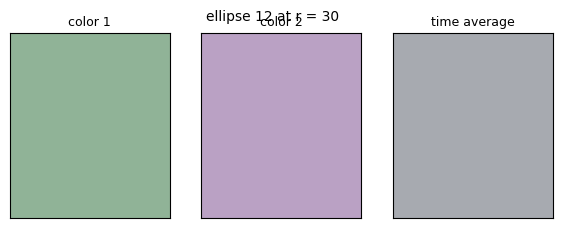

In [8]:
def encode(v):
    'linear -> sRGB, for display on this page'
    v = np.clip(np.asarray(v, float), 0, 1)
    return np.where(v <= 0.0031308, 12.92 * v, 1.055 * v ** (1 / 2.4) - 0.055)


fig, axes = plt.subplots(1, 3, figsize=(7, 2.4))
for ax, c, lab in zip(axes, (c1, c2, (np.array(c1) + np.array(c2)) / 2),
                      ("color 1", "color 2", "time average")):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=encode(c)))
    ax.set_title(lab, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("ellipse %d at r = %d" % (E, R), fontsize=10)
plt.show()

## 4. The model, and where the thresholds come from

Detection is modeled as a function of a single visibility index that combines
the three amplitudes in a Minkowski sum:

$$V(\mathbf{a}) = \left[a_{\mathrm{Lum}}^{k}
   + (w_{\mathrm{RG}} a_{\mathrm{RG}})^{k}
   + (w_{\mathrm{S}} a_{\mathrm{S}})^{k}\right]^{1/k}$$

with $w_{\mathrm{Lum}}$ fixed at 1 to set the scale, and

$$\mathrm{logit}\, P(A) = \beta_0 + \gamma\, V(\mathbf{a}) + u_j$$

where $u_j$ is a random intercept per observer. Fitting that needs the
per-trial responses, so it does not run here; the fitted coefficients are in
`data/axes_fit.json`.

The half-detection threshold of an axis is the amplitude that alone gives
$P(A) = 0.5$, so $T_{\mathrm{Lum}} = -\beta_0/\gamma$ and
$T_{\mathrm{RG}} = T_{\mathrm{Lum}} / w_{\mathrm{RG}}$. The ratio is
$1/w_{\mathrm{RG}}$ and needs no further estimation.

In [9]:
fit = load_json("axes_fit.json")
b0, gam, wr, ws, k = fit["b0"], fit["gam"], fit["wr"], fit["wsB"], fit["k"]
print("beta_0 %.4f   gamma %.3f   w_RG %.4f   w_S %.5f   k %.3f" % (b0, gam, wr, ws, k))
print()
TL = -b0 / gam
print("T_Lum          %.4f" % TL)
print("T_RG           %.4f     ratio T_RG/T_Lum = 1/w_RG = %.3f" % (TL / wr, 1 / wr))
print("T_S (extrap.)  %.3f      ratio T_S/T_Lum  = 1/w_S  = %.1f" % (TL / ws, 1 / ws))

beta_0 -5.0908   gamma 50.737   w_RG 0.8255   w_S 0.06389   k 2.070

T_Lum          0.1003
T_RG           0.1215     ratio T_RG/T_Lum = 1/w_RG = 1.211
T_S (extrap.)  1.570      ratio T_S/T_Lum  = 1/w_S  = 15.7


So at 22.5 Hz the red–green direction tolerates about 1.2 times the luminance
amplitude before becoming equally visible, and the $S$-cone direction tolerates
more than ten times it — far more than the display can even produce, which is
why the $S$ threshold is an extrapolation rather than a measurement.

The exponent $k \approx 2$ means the pathways combine close to in quadrature:
spending part of the budget on one axis leaves most of another axis intact.
Half the luminance allowance costs about an eighth of the red–green allowance,
where a budget that simply added the two would have cost half of it. This is
the $87\%$ the paper quotes.

In [10]:
def V(a_lum, a_rg, a_s):
    return (a_lum ** k + (wr * a_rg) ** k + (ws * a_s) ** k) ** (1 / k)


# Spend a fraction of the luminance allowance and see what red-green is left.
# At the same visibility V = T_Lum, the surviving a_RG follows from
#   a_Lum^k + (w_RG a_RG)^k = T_Lum^k.
for f in (0.0, 0.25, 0.5, 0.75, 1.0):
    left = (max(TL ** k - (f * TL) ** k, 0.0)) ** (1 / k) / wr
    print("   a_Lum = %3.0f%% of T_Lum  ->  %5.1f%% of T_RG still available"
          % (100 * f, 100 * left / (TL / wr)))

   a_Lum =   0% of T_Lum  ->  100.0% of T_RG still available
   a_Lum =  25% of T_Lum  ->   97.2% of T_RG still available
   a_Lum =  50% of T_Lum  ->   87.7% of T_RG still available
   a_Lum =  75% of T_Lum  ->   67.9% of T_RG still available
   a_Lum = 100% of T_Lum  ->    0.0% of T_RG still available


## 5. The ten figures

Each is produced by the script named beside it. They are run here as separate
processes, exactly as `make_figures.py` runs them, so the result is the same
file the manuscript includes. The PNG shown below each is written alongside the
PDF in `out/`.

In [11]:
def build(script, *figures, note=""):
    'Run one figure script and show what it produced.'
    r = subprocess.run([sys.executable, script],
                       cwd=os.path.join(ROOT, "figures"),
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stdout[-2000:], r.stderr[-2000:])
        raise RuntimeError(script + " failed")
    if note:
        print(note)
    tail = [ln for ln in r.stdout.strip().split("\n") if ln.strip()][-3:]
    for ln in tail:
        print("   " + ln)
    for f in figures:
        display(Image(filename=os.path.join(OUT, f + ".png"), width=760))

### Fig. 1 — what the paper is about

Panel (a) is the phenomenon: two colors alternating at 90 Hz frame rate in an
A,A,B,B cycle, giving a 22.5 Hz color vibration whose time average is what the
eye sees. Panel (b) puts two pairs of equal MacAdam radius side by side and
shows their predicted detection differs several-fold. Panel (c) is the same
statement as a map: the chromaticities a fixed detection probability allows,
which is a long thin sliver along the S-cone direction rather than a circle.

Built from the ellipse geometry and the fitted coefficients only.

     E8   field: max P inside gamut 0.874 | on the P=0.2 contour, a_Lum 0.0000-0.0111, dropping it moves P by up to 0.014
     E19  field: max P inside gamut 0.990 | on the P=0.2 contour, a_Lum 0.0000-0.0076, dropping it moves P by up to 0.006
   wrote C:\Users\yuich\Documents\2026_research\vibrosaliency-perception\color-vibration-amplitude-budget\out\fig_concept.pdf


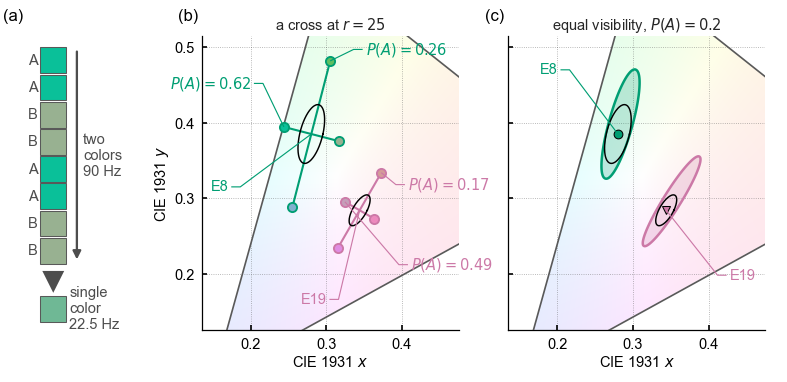

In [12]:
build("gen_fig1g.py", "fig_concept")

### Fig. 2 — the stimuli on the chromaticity diagram

Where the system-A pairs actually sat. Each line runs from a base color outward
along its ellipse's equal-chroma direction; the lead-in below the smallest
measured radius is the solved construction from section 3, not an interpolation.
Needs `conditions.json` and `fine_loci.json`.

      E13  radii [10, 20, 35, 50]
      E14  radii [10, 20]
      E19  radii [20, 30, 40, 50]


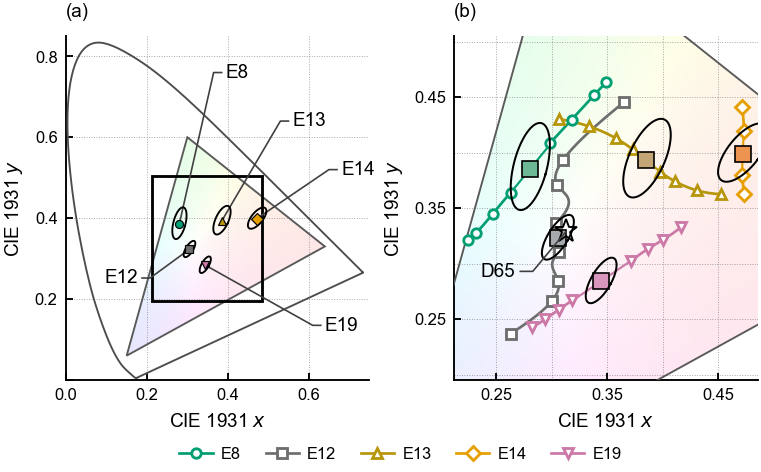

In [13]:
build("gen_xy3.py", "fig_xy")

### Fig. 3 — what those pairs delivered to the three pathways

The same 18 conditions in cone-opponent coordinates. Walking out along an
ellipse by a common radius delivers wildly different mixtures of red–green and
S, which is the whole reason a MacAdam radius fails as an amplitude variable.

   System A conditions: 18
     fig_design
   max a_Lum over all System A conditions: 0.0064


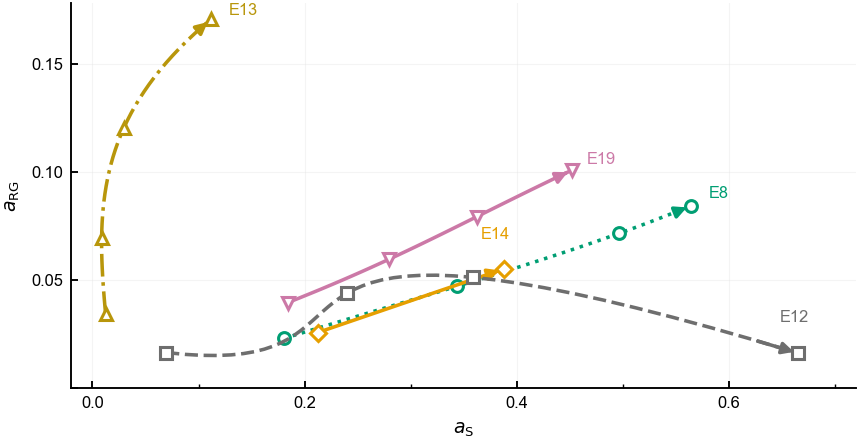

In [14]:
build("gen_design3.py", "fig_design")

### Fig. 4 — the stimulus as presented

Screenshots taken during the experiment, cropped to the same window about the
center of the field. A screenshot catches one frame, so what (b) and (c) show is
one of the two colors of the pair, not the pair.

     9c36f85d7ae4                             crop 800x600
     cc47ce1c5c47                             crop 800x600
     fig_stimulus


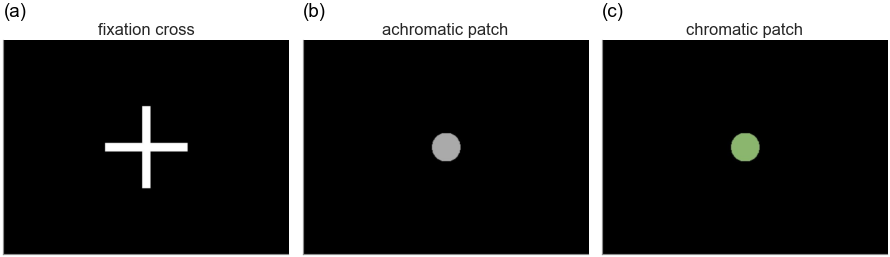

In [15]:
build("gen_stimulus.py", "fig_stimulus")

### Fig. 5 and Fig. 9 — detection against radius, and against the model

Fig. 5 is the raw result for system A: detection rises with the MacAdam radius,
but how fast depends entirely on which ellipse you are on. Fig. 9 is the same
data against what the visibility index predicts, with the weights carried over
from systems B and C and only an intercept and a scale fitted here.

Error bars are the cluster-bootstrap intervals carried in `conditions.json`.

      r=30  a_RG 0.0437  a_S 0.2401   measured 0.364  predicted 0.238
      r=40  a_RG 0.0511  a_S 0.3592   measured 0.352  predicted 0.294
      r=50  a_RG 0.0159  a_S 0.6657   measured 0.273  predicted 0.143


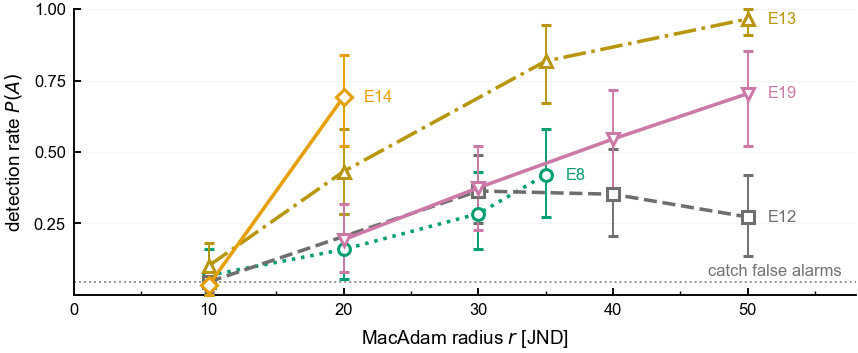

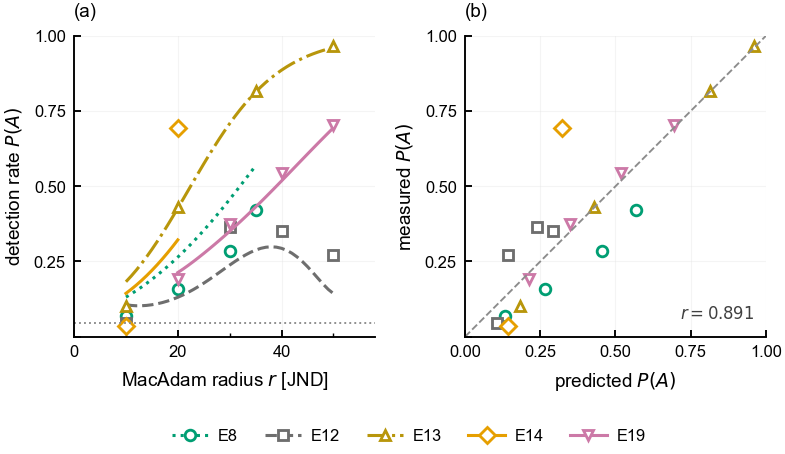

In [16]:
build("gen_rq1_pred.py", "fig_rq1", "fig_pred")

### Fig. 6 and Fig. 8 — the two orthogonal grids

System C crosses luminance against red–green; the curvature of its
iso-detection contour is what pins the exponent $k$ near 2. System B crosses
red–green against S, and shows how little the S direction adds.

     fig_rq4
      System B  a_S   [0.049 0.15  0.249 0.402 0.55  0.7  ]
                a_RG  [0.05 0.09 0.13]


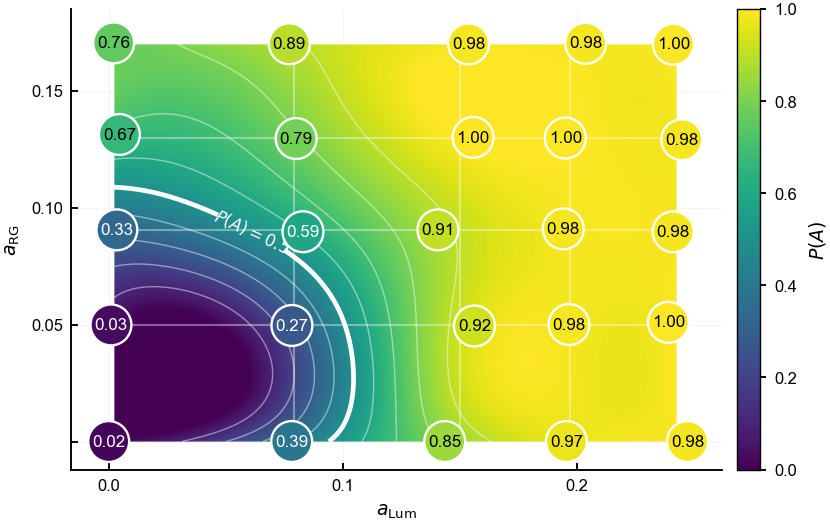

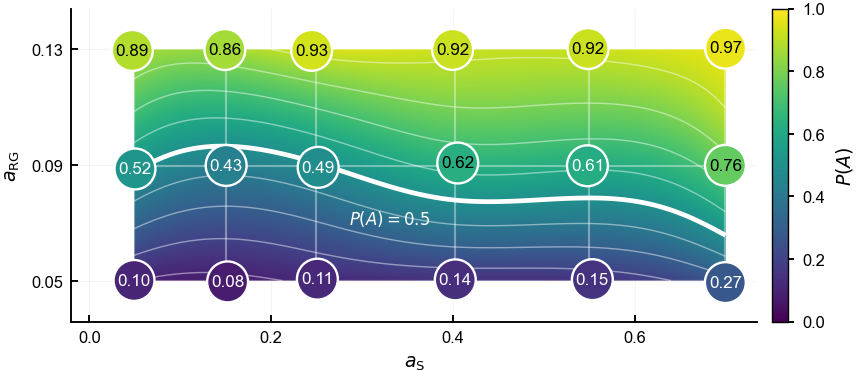

In [17]:
build("gen_grids.py", "fig_rq2", "fig_rq4")

### Fig. 7 — the three axes on one scale

Each series is one axis driven alone, with the fitted psychometric curve it
produced. The thresholds and their profile-likelihood intervals sit on the
half-detection line. The dashed stretch on the S series is extrapolation: it
never reached half detection within the display's gamut.

      $a_{\mathrm{RG}}$ alone extrapolated P(A)=0.50 at 0.122 (not drawn)
      $a_{\mathrm{S}}$, at $a_{\mathrm{RG}}=0.05$ extrapolated P(A)=0.50 at 0.994 (not drawn)
     fig_axes


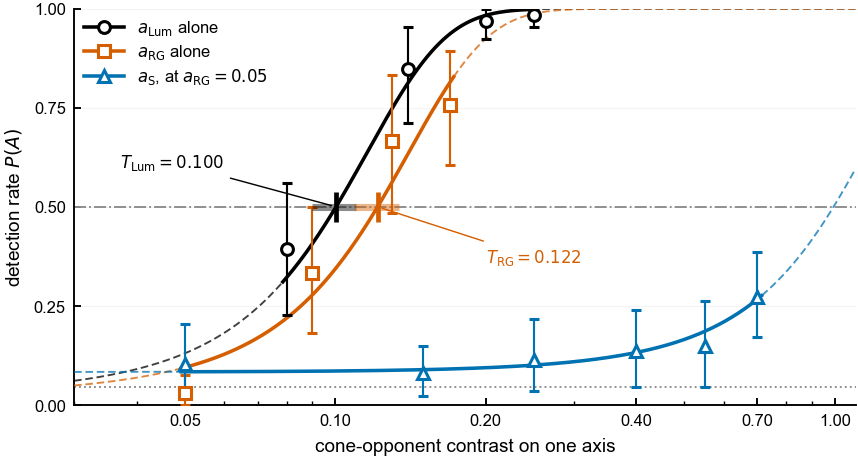

In [18]:
build("gen_axes.py", "fig_axes")

### Fig. 10 — the amplitude budget

The practical output: for a given base color, how far you may move along each
direction before the vibration becomes visible.

     E14  S        1.570        0.589    0.589  (gamut-bound)   0.0462         1.5x
    window x 0.216..0.533  y 0.203..0.602
     fig_budget


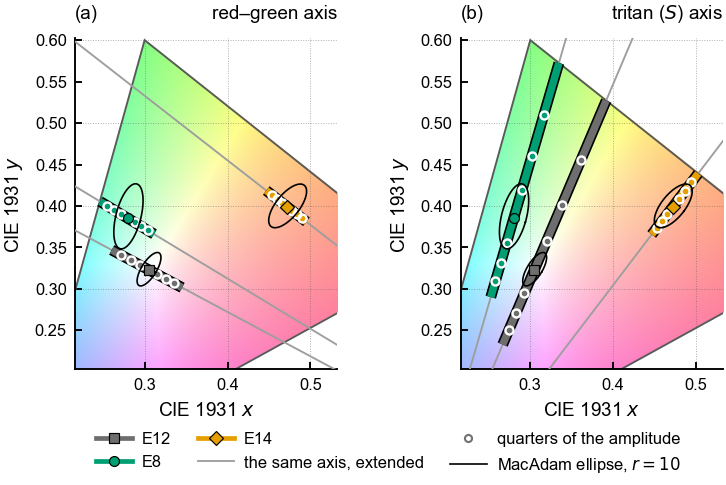

In [19]:
build("gen_budget.py", "fig_budget")

## 6. Using the budget

If you are embedding a signal in a displayed image, the result is a rule of
thumb with numbers attached. At a given base color, the amplitude you may spend
is largest along the S-cone direction, next along red–green, and smallest along
luminance; and because the pathways combine close to in quadrature, spending on
one direction costs you little on another.

Fig. 10 is that rule drawn per direction. `gen_budget.py` computes it, and the
same computation applied to a base color of your own is a matter of calling
`V()` from section 4 with the fitted weights.

To rebuild everything from scratch:

```
python make_figures.py            # the ten figures
python make_figures.py --loci     # re-solve the stimulus construction first
```